# NLP con LSTMs — Notebook 2: Baseline 
**Taller SI3014 · TweetEval Sentiment**
En este notebook entrenamos el modelo base:
| Modelo | Descripción |
|---|---|
| `EmbeddingBaseline` | Promedio de embeddings + Linear. Sin secuencialidad. |
**Pregunta guía:** ¿cuánto aporta modelar el orden de las palabras?

In [1]:
import json
import time
from pathlib import Path
 
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from torch.utils.tensorboard import SummaryWriter
 
from datasets import load_dataset
from tokenizers import Tokenizer
 
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
 
SEED = 42
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


## 1. Cargar artefactos de NB1
NB1 generó dos archivos que reutilizamos aquí:
- `tweet_wordlevel_tokenizer.json` — tokenizer WordLevel entrenado
- `nb1_config.json` — constantes del vocabulario y dataset

In [2]:
tokenizer = Tokenizer.from_file("tweet_wordlevel_tokenizer.json")
 
with open("nb1_config.json") as f:
    config = json.load(f)
 
VOCAB_SIZE = config["vocab_size"]
PAD_IDX    = config["pad_idx"]
MAX_LEN    = config["max_len"]
BATCH_SIZE = config["batch_size"]
NUM_CLASSES = config["num_classes"]
LABEL_NAMES = {int(k): v for k, v in config["label_names"].items()}
 
print(f"Vocab size : {VOCAB_SIZE:,}")
print(f"PAD_IDX    : {PAD_IDX}")
print(f"MAX_LEN    : {MAX_LEN}")
print(f"Clases     : {LABEL_NAMES}")

Vocab size : 19,422
PAD_IDX    : 0
MAX_LEN    : 50
Clases     : {0: 'negative', 1: 'neutral', 2: 'positive'}


## 2. Dataset y DataLoader

Reutilizamos exactamente el mismo pipeline de NB1.

In [3]:
import re
 
def clean_tweet(text: str) -> str:
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "<URL>", text)
    text = re.sub(r"@\w+", "<USER>", text)
    text = re.sub(r"#(\w+)", r"\1", text)
    text = re.sub(r"[^a-z0-9<>\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text
 
 
class TweetDataset(Dataset):
    def __init__(self, hf_split, tokenizer, max_len=MAX_LEN):
        self.data = hf_split
        self.tokenizer = tokenizer
        self.max_len = max_len
 
    def __len__(self):
        return len(self.data)
 
    def __getitem__(self, idx):
        example = self.data[idx]
        ids = self.tokenizer.encode(clean_tweet(example["text"])).ids[:self.max_len]
        return (
            torch.tensor(ids, dtype=torch.long),
            torch.tensor(example["label"], dtype=torch.long),
        )
 
 
def collate_fn(batch):
    sequences, labels = zip(*batch)
    lengths = torch.tensor([len(s) for s in sequences], dtype=torch.long)
    padded  = pad_sequence(sequences, batch_first=True, padding_value=PAD_IDX)
    return padded, torch.stack(labels), lengths   # devolvemos lengths para pack_padded

In [4]:
dataset = load_dataset("tweet_eval", "sentiment")
 
train_loader = DataLoader(TweetDataset(dataset["train"], tokenizer),
                          batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(TweetDataset(dataset["validation"], tokenizer),
                          batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(TweetDataset(dataset["test"], tokenizer),
                          batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
 
print(f"Batches — train: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}")

Batches — train: 713 | val: 32 | test: 192


## 3. Modelos

### 3.1 Baseline — Promedio de embeddings

La idea más simple posible: representar un tweet como el **promedio**
de los vectores de sus palabras, ignorando el orden.
Si este modelo ya clasifica bien, el orden no importa mucho.
```
ids (B, L) → Embedding (B, L, E) → mean sobre L (ignora PAD) → Linear → logits (B, C)
```

In [25]:
class LSTM(nn.Module):
    """
    Clasificador de bolsa de palabras (mean pooling de embeddings).
 
    Parámetros
    ----------
    vocab_size : int
    embed_dim  : int   Dimensión de los embeddings.
    num_classes: int
    pad_idx    : int   Índice de <PAD>; sus gradientes no se actualizan.
    """
    def __init__(self, vocab_size: int, embed_dim: int,
                 hidden_size: int, num_classes: int, pad_idx: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm   = nn.LSTM(input_size=embed_dim, hidden_size=hidden_size, num_layers = 5, dropout = 0.2, batch_first=True)
        self.classifier = nn.Linear(hidden_size, num_classes)
 
    def forward(self, ids, lengths):
        emb = self.embedding(ids)                          # (B, L, E)

        packed = nn.utils.rnn.pack_padded_sequence(
            emb, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, (h_n, _) = self.lstm(packed)                   # h_n: (1, B, H)

        return self.classifier(h_n[0]) 
 
# Prueba rápida de shapes
_model = LSTM(VOCAB_SIZE, 16, 64, NUM_CLASSES, PAD_IDX).to(DEVICE)
_ids, _labels, _lengths = next(iter(train_loader))
_ids, _lengths = _ids.to(DEVICE), _lengths.to(DEVICE)
print("Baseline output shape:", _model(_ids, _lengths).shape)  # (B, 3)
del _model
 

Baseline output shape: torch.Size([64, 3])


In [26]:
def run_epoch(model, loader, criterion, optimizer=None):
    """
    Ejecuta una época de train o eval.
 
    Si optimizer es None → modo eval (sin gradientes).
    Retorna (avg_loss, accuracy).
    """
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss, correct, n = 0.0, 0, 0
 
    with torch.set_grad_enabled(training):
        for ids, labels, lengths in loader:
            ids, labels, lengths = ids.to(DEVICE), labels.to(DEVICE), lengths.to(DEVICE)
            preds = model(ids, lengths)
            loss  = criterion(preds, labels)
            if training:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            total_loss += loss.item() * ids.size(0)
            correct    += (preds.argmax(dim=1) == labels).sum().item()
            n          += ids.size(0)
 
    return total_loss / n, correct / n

In [27]:
@torch.no_grad()
def evaluate_clf(model, loader, criterion):
    """
    Igual que run_epoch en modo eval, pero también acumula
    predicciones y etiquetas para classification_report.
    """
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    all_preds, all_labels  = [], []
 
    for ids, labels, lengths in loader:
        ids, labels, lengths = ids.to(DEVICE), labels.to(DEVICE), lengths.to(DEVICE)
        logits = model(ids, lengths)
        loss   = criterion(logits, labels)
        preds  = logits.argmax(dim=1)
 
        total_loss += loss.item() * ids.size(0)
        correct    += (preds == labels).sum().item()
        n          += ids.size(0)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
 
    return total_loss / n, correct / n, all_preds, all_labels

In [28]:
class ModelCheckpoint:
    """Guarda el mejor modelo según una métrica monitoreada."""
    def __init__(self, filepath, monitor="val_acc", mode="max", verbose=True):
        self.filepath = filepath
        self.monitor  = monitor
        self.verbose  = verbose
        self.best     = float("-inf") if mode == "max" else float("inf")
        self.mode     = mode
 
    def step(self, metrics, model):
        value    = metrics[self.monitor]
        improved = value > self.best if self.mode == "max" else value < self.best
        if improved:
            self.best = value
            torch.save(model.state_dict(), self.filepath)
            if self.verbose:
                print(f"  ✓ Mejor modelo guardado ({self.monitor}: {value:.4f})")
        return improved

## 5. Entrenamiento

In [29]:
EMBED_DIM  = 16
HIDDEN_DIM = 64
EPOCHS     = 10
LR         = 1e-3
 
criterion = nn.CrossEntropyLoss()

### 5.1 Baseline
El modelo está completo. Verifica que `run_epoch` funciona correctamente
antes de implementar el LSTM.

In [30]:
baseline     = LSTM(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_CLASSES, PAD_IDX).to(DEVICE)
opt_baseline = torch.optim.Adam(baseline.parameters(), lr=LR)
ckpt_baseline = ModelCheckpoint("baseline_best.pt", monitor="val_acc")
 
print(f"Parámetros baseline: {sum(p.numel() for p in baseline.parameters()):,}")
 
history_baseline = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
writer = SummaryWriter(log_dir="runs/baseline")
 
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(baseline, train_loader, criterion, opt_baseline)
    val_loss,   val_acc   = run_epoch(baseline, val_loader,   criterion)
 
    history_baseline["train_loss"].append(train_loss)
    history_baseline["val_loss"].append(val_loss)
    history_baseline["train_acc"].append(train_acc)
    history_baseline["val_acc"].append(val_acc)
 
    writer.add_scalars("Loss",     {"train": train_loss, "val": val_loss}, epoch)
    writer.add_scalars("Accuracy", {"train": train_acc,  "val": val_acc},  epoch)
 
    print(f"Epoch {epoch:02d}/{EPOCHS} — "
          f"train loss: {train_loss:.4f}, acc: {train_acc:.3f} | "
          f"val loss: {val_loss:.4f}, acc: {val_acc:.3f}")
 
    ckpt_baseline.step({"val_acc": val_acc}, baseline)
 
writer.close()

Parámetros baseline: 465,059
Epoch 01/10 — train loss: 1.0029, acc: 0.473 | val loss: 0.9748, acc: 0.502
  ✓ Mejor modelo guardado (val_acc: 0.5025)
Epoch 02/10 — train loss: 0.9047, acc: 0.565 | val loss: 0.8966, acc: 0.569
  ✓ Mejor modelo guardado (val_acc: 0.5690)
Epoch 03/10 — train loss: 0.8219, acc: 0.615 | val loss: 0.8563, acc: 0.603
  ✓ Mejor modelo guardado (val_acc: 0.6025)
Epoch 04/10 — train loss: 0.7674, acc: 0.647 | val loss: 0.8326, acc: 0.604
  ✓ Mejor modelo guardado (val_acc: 0.6035)
Epoch 05/10 — train loss: 0.7202, acc: 0.673 | val loss: 0.8287, acc: 0.631
  ✓ Mejor modelo guardado (val_acc: 0.6315)
Epoch 06/10 — train loss: 0.6788, acc: 0.697 | val loss: 0.8103, acc: 0.643
  ✓ Mejor modelo guardado (val_acc: 0.6435)
Epoch 07/10 — train loss: 0.6412, acc: 0.719 | val loss: 0.7924, acc: 0.656
  ✓ Mejor modelo guardado (val_acc: 0.6565)
Epoch 08/10 — train loss: 0.6084, acc: 0.738 | val loss: 0.8187, acc: 0.649
Epoch 09/10 — train loss: 0.5759, acc: 0.753 | val loss

In [32]:
## 6. Evaluación en test
 
# %%
def plot_history(histories: dict):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for name, h in histories.items():
        axes[0].plot(h["train_loss"], label=f"{name} train")
        axes[0].plot(h["val_loss"],   label=f"{name} val", linestyle="--")
        axes[1].plot(h["train_acc"],  label=f"{name} train")
        axes[1].plot(h["val_acc"],    label=f"{name} val", linestyle="--")
    axes[0].set_title("Loss"); axes[0].legend(); axes[0].set_xlabel("Época")
    axes[1].set_title("Accuracy"); axes[1].legend(); axes[1].set_xlabel("Época")
    plt.tight_layout()
    plt.show()
 
 
def full_report(model, loader, model_name: str):
    """Classification report + doble matriz de confusión (conteos y proporciones)."""
    target_names = [LABEL_NAMES[i] for i in range(NUM_CLASSES)]
    _, acc, preds, labels = evaluate_clf(model, loader, criterion)
 
    print(f"\n{'='*50}")
    print(f"  {model_name} — Test Accuracy: {acc:.4f}")
    print(f"{'='*50}")
    print(classification_report(labels, preds, target_names=target_names, digits=4))
 
    cm      = confusion_matrix(labels, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
 
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, data, fmt, title in zip(
        axes,
        [cm, cm_norm],
        ["d", ".2f"],
        ["Conteos absolutos", "Proporción por clase (recall)"],
    ):
        sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                    xticklabels=target_names, yticklabels=target_names, ax=ax)
        ax.set_xlabel("Predicción"); ax.set_ylabel("Real")
        ax.set_title(f"{model_name}\n{title}")
    plt.tight_layout()
    plt.show()


  Baseline (mean pooling) — Test Accuracy: 0.5729
              precision    recall  f1-score   support

    negative     0.6030    0.4474    0.5137      3972
     neutral     0.5930    0.6495    0.6200      5937
    positive     0.4952    0.5912    0.5390      2375

    accuracy                         0.5729     12284
   macro avg     0.5638    0.5627    0.5575     12284
weighted avg     0.5774    0.5729    0.5699     12284



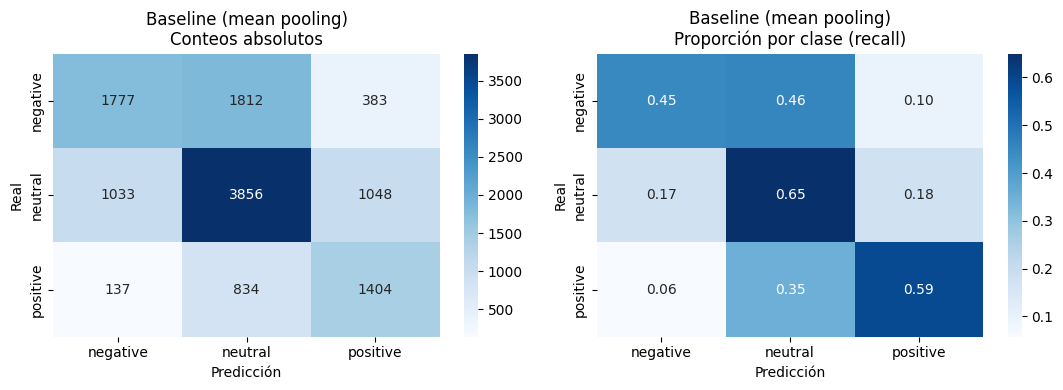

In [24]:
# Carga el mejor checkpoint antes de evaluar en test
baseline.load_state_dict(torch.load("baseline_best.pt", map_location=DEVICE))
full_report(baseline, test_loader, "Baseline (mean pooling)")